# CE 310 — Week 10 Lab: Multiple Linear Regression
## Adding Predictors — Occupancy, Season, and Interaction Effects

**Dataset:** DOE Reference Medium Office Building, Tucson/Phoenix Climate Zone 2B  
**Tools:** pandas · matplotlib · scipy.stats · statsmodels  
**Submission:** Download as .ipynb (File → Download → Download .ipynb) and submit to D2L

## Before You Begin

**File needed:** `Week5_DOE_MedOffice_ZoneTemp_2023.csv`  
This is the **same dataset** you used in Weeks 5–7 (Excel labs) and Week 9 (your first Python lab). This is the third lab using this file — you already know the columns.

**Upload options:**
1. **Colab Files panel (easiest):** Click the folder icon in the left sidebar → click the upload icon → select the CSV file from your computer.
2. **Google Drive mount:** If your file is already in Google Drive, click the Drive mount button in the Files panel and navigate to the file.

> If you see `FileNotFoundError`, the CSV is not in Colab's working directory — go back and upload it first.

**New this week:** We add `statsmodels` — a Python library that produces full regression summary tables including p-values, confidence intervals, and Adjusted R². It is pre-installed in Google Colab.

## Pacing Guide

## Background

In Week 9, outdoor temperature explained **60.1%** of the variance in cooling energy (R² = 0.601). What about the other **39.9%**?

One answer: *whether the building is occupied*. On a 75°F morning with nobody in the building, the HVAC runs lightly. On a 75°F afternoon with 200 people, computers, and lights running, it works much harder — even at the same outdoor temperature. Today you add `BusinessHours` as a second predictor and discover it adds **10 percentage points** of R².

| Design Question | Simple regression limit | Multiple regression answer |
|---|---|---|
| How much does occupancy add to cooling load? | Can't separate from outdoor temp | BH coefficient ≈ 18 kWh/hr occupied premium |
| Does adding Season improve the model? | N/A | Season and outdoor temp are collinear — almost no improvement |
| Is the temperature sensitivity different when occupied? | Same slope assumed for all hours | Interaction term: occupied slope = 1.78 vs. unoccupied = 0.71 kWh/°F |

**Machine learning bridge:** Adding predictors to a regression model is called **feature engineering** in machine learning. Interaction terms — where one feature changes the effect of another — are the foundation of how tree-based models (random forests, gradient boosting) learn non-linear relationships. Today's interaction model is the simplest possible version of this idea.

## Week 9 Looking-Ahead Answer

In Week 9 you were asked: *If you added BusinessHours as a second predictor alongside Outdoor_Temp_F, would R² go up, go down, or stay the same?*

**Answer:** R² increases from **0.601 to 0.697** — a gain of **+9.6 percentage points**.

Outdoor temperature alone cannot distinguish a vacant weekend night from a Monday afternoon at the same temperature. `BusinessHours` captures that difference: once the building is occupied, people, computers, and lighting add heat loads that HVAC must remove regardless of what's happening outdoors.

In [ ]:
# pandas, numpy, matplotlib, scipy.stats — already familiar from Week 9
# NEW this week: statsmodels — full regression tables with p-values, confidence intervals
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf  # ← new: formula-based regression

df = pd.read_csv('Week5_DOE_MedOffice_ZoneTemp_2023.csv')

# Create BusinessHours dummy variable: 1 = occupied, 0 = unoccupied
df['BH'] = (df['BusinessHours'] == 'Yes').astype(int)

print(f"Rows: {df.shape[0]}")
print(f"Occupied hours (BH=1): {df['BH'].sum()}")
print(f"Unoccupied hours (BH=0): {(df['BH']==0).sum()}")
df.head(3)

---
## Section A: Occupancy & Baseline Exploration (~25 min)

Before fitting a model, confirm how occupancy affects cooling. The answers here will be compared to the regression coefficients in Section B — the difference between the raw group means and the regression coefficients is an important lesson about **confounding**.

**Python reminders:**
- `df[df['col'] == val]` filters rows where column equals val
- `df.groupby('col')['other'].mean()` computes group means
- `df['col1'].corr(df['col2'])` computes Pearson r between two columns

In [ ]:
# ── A1 ────────────────────────────────────────────────────────────────
# How many unique Season values are in this dataset?
# Hint: df['Season'].nunique()

ANSWER_A1 = df['Season'].nunique()

print(f"ANSWER_A1 = {ANSWER_A1}")
print(f"Season values: {sorted(df['Season'].unique())}")

In [ ]:
# ── A2 ────────────────────────────────────────────────────────────────
# How many occupied hours are there (BH = 1)?
# Hint: df['BH'].sum()

ANSWER_A2 = df['BH'].sum()

print(f"ANSWER_A2 = {ANSWER_A2}")
print(f"Unoccupied hours (BH=0): {(df['BH']==0).sum()}")
print(f"Fraction occupied: {ANSWER_A2 / len(df):.1%}")

In [ ]:
# ── A3 ────────────────────────────────────────────────────────────────
# What is the mean Cooling_kWh during occupied hours (BH=1)? Round to 2 dp.

ANSWER_A3 = round(df[df['BH'] == 1]['Cooling_kWh'].mean(), 2)

print(f"ANSWER_A3 = {ANSWER_A3} kWh/hr (mean cooling, occupied hours)")

In [ ]:
# ── A4 ────────────────────────────────────────────────────────────────
# What is the mean Cooling_kWh during unoccupied hours (BH=0)? Round to 2 dp.

ANSWER_A4 = round(df[df['BH'] == 0]['Cooling_kWh'].mean(), 2)

print(f"ANSWER_A4 = {ANSWER_A4} kWh/hr (mean cooling, unoccupied hours)")

In [ ]:
# ── A5 ────────────────────────────────────────────────────────────────
# What is the occupied minus unoccupied mean cooling? (raw occupancy premium)

ANSWER_A5 = round(ANSWER_A3 - ANSWER_A4, 2)

print(f"ANSWER_A5 = {ANSWER_A5} kWh/hr (raw occupancy premium)")
print()
# This is the raw difference. The regression coefficient in Model 2 (BH ≈ 18 kWh) will
# be SMALLER because it controls for outdoor temperature — occupied hours also tend to
# occur during the warmer part of the day. This is called confounding.

In [ ]:
# ── A6 ────────────────────────────────────────────────────────────────
# What is the mean outdoor temperature during occupied vs. unoccupied hours?
# This reveals confounding: BH and Outdoor_Temp are correlated.

ANSWER_A6_occupied   = round(df[df['BH'] == 1]['Outdoor_Temp_F'].mean(), 2)
ANSWER_A6_unoccupied = round(df[df['BH'] == 0]['Outdoor_Temp_F'].mean(), 2)

print(f"ANSWER_A6_occupied   = {ANSWER_A6_occupied} °F")
print(f"ANSWER_A6_unoccupied = {ANSWER_A6_unoccupied} °F")
print(f"Difference: {ANSWER_A6_occupied - ANSWER_A6_unoccupied:.2f} °F")
print()
# The occupied mean outdoor temp is higher because business hours coincide with
# daytime (warmer). This is *confounding* — BH and Outdoor_Temp are correlated,
# so the simple mean difference in A5 OVERSTATES the true occupancy effect.

In [ ]:
# ── A7 ────────────────────────────────────────────────────────────────
# What is the Pearson correlation between BH and Outdoor_Temp_F?
# This directly quantifies the multicollinearity between these two predictors.

ANSWER_A7 = round(df['BH'].corr(df['Outdoor_Temp_F']), 4)

print(f"ANSWER_A7 = {ANSWER_A7}")
print(f"Interpretation: r = {ANSWER_A7} confirms BH and Outdoor_Temp_F are moderately correlated.")
print("This is why the raw group mean difference (A5) overstates the regression BH coefficient.")


*VIF (ungraded): The Variance Inflation Factor quantifies how much the variance of a coefficient estimate is inflated by multicollinearity. `VIF = 1 / (1 − R²_j)` where R²_j is the R² from regressing predictor j on all other predictors. A common rule of thumb: VIF > 5 signals problematic multicollinearity; VIF > 10 is severe. For the BH–Outdoor_Temp_F pair, r ≈ 0.37, so R²_j ≈ 0.14 and VIF ≈ 1.16 — well below any threshold. Multicollinearity exists but is mild enough that both coefficients are reliably estimated. You will see this confirmed in the regression summary: both have very small standard errors relative to their coefficients.*


In [ ]:
# ── A8 ────────────────────────────────────────────────────────────────
# Week 9 baseline R² — hardcoded as a reminder for comparison throughout Section B.

ANSWER_A8_wk9_r2 = 0.6010

print(f"ANSWER_A8_wk9_r2 = {ANSWER_A8_wk9_r2}")
print("(Week 9 baseline: simple regression Cooling_kWh ~ Outdoor_Temp_F)")
print("We will compare every new model's R² to this baseline.")

---
## Section B: Multiple Regression Models

In [ ]:
# ── B1: Fit Model 2 — Cooling ~ Outdoor_Temp_F + BH ──────────────────
# statsmodels formula API: specify the model as a string
# '~' separates outcome from predictors; '+' adds predictors

model2 = smf.ols('Cooling_kWh ~ Outdoor_Temp_F + BH', data=df).fit()
print(model2.summary())

**How to read the statsmodels summary:**

- **R-squared** and **Adj. R-squared**: top section, lines 3–4
- **coef column**: the estimated coefficient for each predictor
- **P>|t| column**: p-value for H₀: coefficient = 0. Values < 0.05 are statistically significant (marked with `***`)
- **[0.025  0.975] columns**: 95% confidence interval for each coefficient

For Model 2, you should see three rows in the coefficient table:
- `Intercept` — predicted cooling when outdoor temp = 0 and building is unoccupied
- `Outdoor_Temp_F` — slope: kWh/hr increase per 1°F rise in outdoor temp (holding BH constant)
- `BH` — occupancy premium: extra kWh/hr when occupied vs. unoccupied (holding outdoor temp constant)

In [ ]:
# ── B2: Extract R² and Adj. R² from Model 2 ──────────────────────────

ANSWER_B2_r2     = round(model2.rsquared, 4)
ANSWER_B2_adj_r2 = round(model2.rsquared_adj, 4)

print(f"ANSWER_B2_r2     = {ANSWER_B2_r2}")
print(f"ANSWER_B2_adj_r2 = {ANSWER_B2_adj_r2}")
print(f"R² improvement over Week 9: {ANSWER_B2_r2 - 0.6010:+.4f}")

In [ ]:
# ── B3 ★: BH coefficient — record, CI, and interpret ─────────────────
# This is the starred question: record the value AND fill in the interpretation
# markdown cell below.

ANSWER_B3_BH_coef = round(model2.params['BH'], 3)
ANSWER_B3_BH_pval = model2.pvalues['BH']

# 95% CI for the BH coefficient (from statsmodels conf_int())
_ci = model2.conf_int()
ANSWER_B3_BH_ci_lo = round(float(_ci.loc['BH', 0]), 3)
ANSWER_B3_BH_ci_hi = round(float(_ci.loc['BH', 1]), 3)

print(f"ANSWER_B3_BH_coef  = {ANSWER_B3_BH_coef} kWh/hr")
print(f"p-value for BH coefficient: {ANSWER_B3_BH_pval:.2e}")
print(f"ANSWER_B3_BH_ci_lo = {ANSWER_B3_BH_ci_lo}")
print(f"ANSWER_B3_BH_ci_hi = {ANSWER_B3_BH_ci_hi}")
print(f"95% CI: [{ANSWER_B3_BH_ci_lo}, {ANSWER_B3_BH_ci_hi}] kWh/hr")

**B3 Interpretation (fill in):**

Holding outdoor temperature constant, occupied hours require ___ kWh/hr more cooling than unoccupied hours. This is statistically significant (p ≈ ___).

The occupied premium reflects internal heat gains from [fill in: people, lighting, computers, etc.] that exist regardless of outdoor conditions. Compare this to the raw mean difference you computed in A5 (___ kWh/hr) — why is the regression coefficient smaller than the raw group difference?

In [ ]:
# ── B4: Outdoor_Temp_F coefficient in Model 2 vs. Week 9 ─────────────

ANSWER_B4_slope_m2 = round(model2.params['Outdoor_Temp_F'], 4)
wk9_slope = 1.1585

print(f"ANSWER_B4_slope_m2 = {ANSWER_B4_slope_m2} kWh/°F")
print(f"Week 9 slope:       {wk9_slope} kWh/°F")
print(f"Change:             {ANSWER_B4_slope_m2 - wk9_slope:+.4f} kWh/°F")
print()
# The slope decreased because Model 2 now controls for BH.
# In Week 9, the slope was inflated because occupied hours (hotter + higher cooling)
# were mixed with unoccupied hours. Controlling for BH removes this bias.

In [ ]:
# ── B5: Fit Model 3 — Cooling ~ Outdoor_Temp_F + C(Season) ───────────
# C(Season) tells statsmodels to treat Season as a categorical variable.
# The reference category (absorbed into the intercept) is 'Fall' (alphabetically first).

model3 = smf.ols('Cooling_kWh ~ Outdoor_Temp_F + C(Season)', data=df).fit()
ANSWER_B5_r2_m3 = round(model3.rsquared, 4)

print(f"ANSWER_B5_r2_m3 = {ANSWER_B5_r2_m3}")
print(f"Model 2 R² (+BH):    {ANSWER_B2_r2}  |  Model 3 R² (+Season): {ANSWER_B5_r2_m3}")
print(f"Which adds more to simple regression — BH or Season?")
print()
# Season and Outdoor_Temp_F are collinear — they measure similar information.
# Summer is hot; Winter is cold. Once outdoor temp is in the model, Season adds almost nothing.

In [ ]:
# ── B6: Prediction comparison at design temperature ───────────────────
# Predict cooling at 108°F (ASHRAE 1% design condition, Climate Zone 2B)
# for occupied vs. unoccupied using Model 2.

pred_108_occupied   = (model2.params['Intercept']
                       + model2.params['Outdoor_Temp_F'] * 108
                       + model2.params['BH'] * 1)
pred_108_unoccupied = (model2.params['Intercept']
                       + model2.params['Outdoor_Temp_F'] * 108
                       + model2.params['BH'] * 0)

ANSWER_B6_occupied   = round(pred_108_occupied, 1)
ANSWER_B6_unoccupied = round(pred_108_unoccupied, 1)

print(f"ANSWER_B6_occupied   = {ANSWER_B6_occupied} kWh/hr at 108°F")
print(f"ANSWER_B6_unoccupied = {ANSWER_B6_unoccupied} kWh/hr at 108°F")
print(f"Occupied premium at peak temp: {ANSWER_B6_occupied - ANSWER_B6_unoccupied:.1f} kWh/hr")

---

In [ ]:
# ── B7: Interaction model — Cooling ~ Outdoor_Temp_F * BH ─────────────
# Outdoor_Temp_F * BH creates BOTH main effects AND their interaction.
# Interpretation: the slope of outdoor temp is DIFFERENT when occupied vs. unoccupied.

model5 = smf.ols('Cooling_kWh ~ Outdoor_Temp_F * BH', data=df).fit()
print(model5.summary())

**Reading the interaction model summary:**

The coefficient table now has **four rows**:
- `Intercept` — unoccupied intercept (predicted cooling at 0°F, unoccupied)
- `Outdoor_Temp_F` — slope when **unoccupied** (BH = 0)
- `BH` — shift in intercept when occupied vs. unoccupied
- `Outdoor_Temp_F:BH` — **extra slope per degree when occupied**: how much MORE each °F adds when occupied

The full slope when occupied = `Outdoor_Temp_F` coeff + `Outdoor_Temp_F:BH` coeff.

Fill in B3 Interpretation and B8 below using these four coefficients.

In [ ]:
# ── B8 ★: Interaction coefficient — record and compute slopes ──────────

ANSWER_B8_interaction = round(model5.params['Outdoor_Temp_F:BH'], 4)
slope_unoccupied = round(model5.params['Outdoor_Temp_F'], 4)
slope_occupied   = round(model5.params['Outdoor_Temp_F'] + model5.params['Outdoor_Temp_F:BH'], 4)

print(f"ANSWER_B8_interaction  = {ANSWER_B8_interaction} kWh/°F (extra slope when occupied)")
print(f"Unoccupied slope       = {slope_unoccupied} kWh/°F")
print(f"Occupied slope         = {slope_occupied} kWh/°F")
print(f"Compare occupied slope to Week 9 Assignment P1d business-hours result: 1.7813 kWh/°F")

In [ ]:
# ── B9: R² comparison across all models ───────────────────────────────
# First, fit Model 4 (+BH +Season) so we can include it in the table.

model4 = smf.ols('Cooling_kWh ~ Outdoor_Temp_F + BH + C(Season)', data=df).fit()
ANSWER_B9_r2_m4          = round(model4.rsquared, 4)
ANSWER_B9_r2_interaction = round(model5.rsquared, 4)

print(f"ANSWER_B9_r2_interaction = {ANSWER_B9_r2_interaction}")
print(f"ANSWER_B9_r2_m4          = {ANSWER_B9_r2_m4}")
print()
print("R² progression:")
print(f"  Week 9 simple:           0.6010")
print(f"  + BusinessHours (M2):    {ANSWER_B2_r2}")
print(f"  + Season only (M3):      {ANSWER_B5_r2_m3}")
print(f"  + BH + Season (M4):      {ANSWER_B9_r2_m4}")
print(f"  Interaction Temp*BH (M5): {ANSWER_B9_r2_interaction}")

**Target shape for B10:**

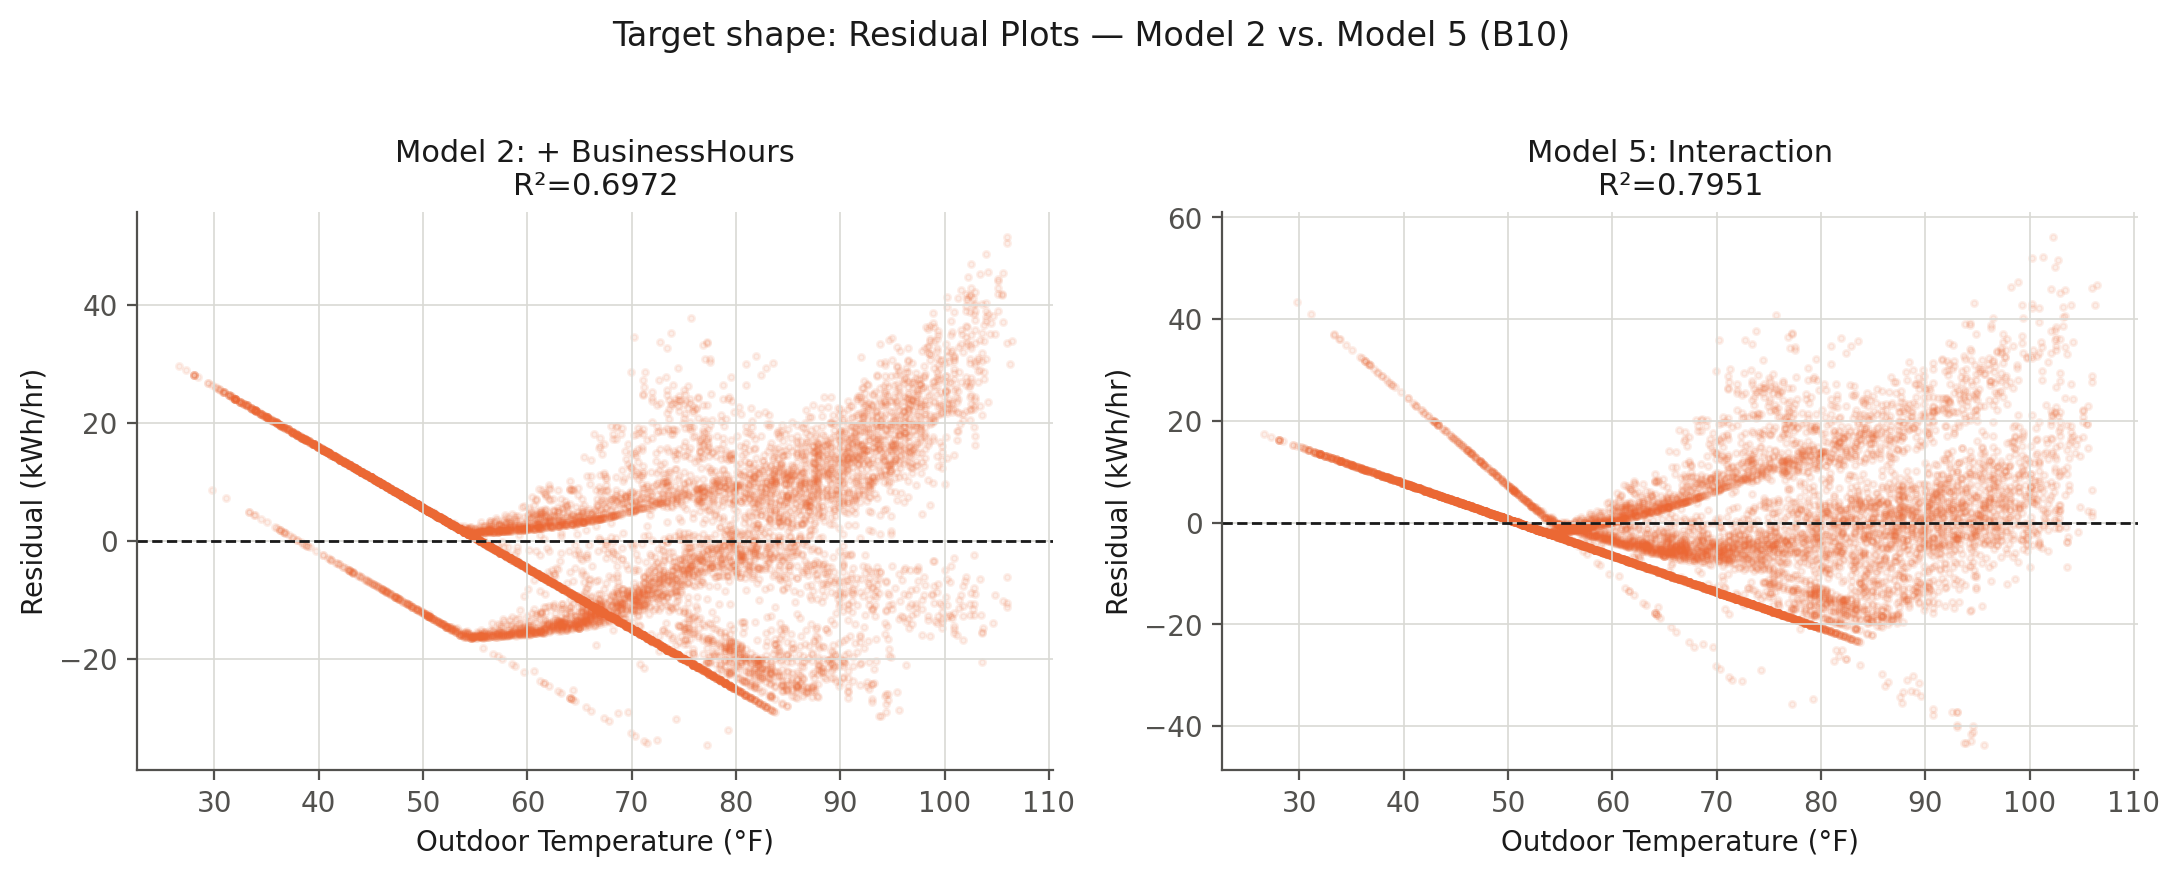


In [ ]:
# ── B10: Residual plots — Model 2 vs. Model 5 ─────────────────────────
# Side-by-side comparison: does the interaction model reduce systematic residual patterns?

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, model, title in zip(axes,
                             [model2, model5],
                             ['Model 2: + BusinessHours', 'Model 5: Interaction']):
    resid = model.resid
    ax.scatter(df['Outdoor_Temp_F'], resid, alpha=0.1, s=4, color='orange')
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    ax.set_xlabel('Outdoor Temperature (°F)')
    ax.set_ylabel('Residual (kWh/hr)')
    ax.set_title(f'{title}\nR²={model.rsquared:.4f}')

plt.tight_layout()
plt.show()

# Look at the pattern at low outdoor temps and at the spread of residuals overall.
# Does the interaction model reduce the systematic structure visible in Model 2?

In [ ]:
# ── B11: AIC comparison (model selection) ─────────────────────────────
# AIC (Akaike Information Criterion): lower is better; penalizes for complexity.
# Unlike R², AIC can decrease when a predictor adds little information.

model1_simple = smf.ols('Cooling_kWh ~ Outdoor_Temp_F', data=df).fit()

print("AIC comparison (lower = better fit per complexity):")
print(f"  Week 9 simple:          {model1_simple.aic:.1f}")
print(f"  Model 2 (+BH):          {model2.aic:.1f}")
print(f"  Model 3 (+Season):      {model3.aic:.1f}")
print(f"  Model 4 (+BH+Season):   {model4.aic:.1f}")
print(f"  Model 5 (interaction):  {model5.aic:.1f}")
print()

ANSWER_B11_best_model = 5  # ← the model with the lowest AIC
print(f"ANSWER_B11_best_model = {ANSWER_B11_best_model}")
print("(Model 5 — interaction — has the lowest AIC by a large margin.)")

---
## Looking Ahead — Week 11

Week 11 introduces **hypothesis testing**. You already used p-values this week to test whether individual regression coefficients are zero. Week 11 formalizes this: the **two-sample t-test** tests whether the *mean* of one group differs from another.

**Before next class, think:** You know that occupied and unoccupied hours have different mean cooling (A3: 38.86 kWh vs. A4: 10.56 kWh). How would you formally test whether that difference is statistically significant? What would the null hypothesis be? How would the answer relate to the BH coefficient you computed today?

---
## Memo — Week 10

**To:** Building Engineer  
**From:** [Your Name]  
**Re:** Multiple Regression Model — Cooling Energy, Occupancy, and Interaction Effects

---

**Paragraph 1 — Model Summary:**  
[Fill in: state the Model 2 equation with the actual coefficient values. Report R² = 0.697 and Adj. R² = 0.697. What fraction of cooling variance is now explained? What does the BH coefficient represent physically? How does this compare to Week 9's R² = 0.601?]

---

**Paragraph 2 — Engineering Interpretation:**  
[Fill in: what does the 17.9 kWh/hr occupancy premium mean for HVAC sizing? How does the design-day prediction change between occupied (71.8 kWh/hr at 108°F) and unoccupied (53.9 kWh/hr at 108°F) scenarios? If a facility manager oversizes the HVAC for occupied conditions but the building is sometimes unoccupied during peak heat events, is the additive model conservative or under-conservative?]

---

**Paragraph 3 — Model Choice:**  
[Fill in: the interaction model (R² = 0.795) outperforms the additive model (R² = 0.697). The interaction model shows that occupied buildings are more than twice as sensitive to outdoor temperature (slope 1.78 vs. 0.71 kWh/°F). Which model would you recommend to a client? What is the trade-off between interpretability and accuracy? In what design scenario would the extra accuracy of the interaction model matter most?]

---
## Before You Submit

> ⚠️ Your saved cell **outputs** are what get read, not your code. If you skip this step, every numeric question scores 0 — even if your formulas are correct.

**Step 1 — Run All Cells:**
In the menu bar: **Runtime → Run all** (Google Colab) or **Kernel → Restart & Run All** (Jupyter).
Wait until every cell shows output — no spinning circles.

**Step 2 — Check your ANSWER_ lines:**
Each graded cell should print a line like `ANSWER_A1 = 23.45`. If any prints `None` or is missing, fix the code and re-run.

**Step 3 — Download and upload:**
- File → Download → **Download .ipynb** (not PDF, not .py)
- Rename: `lastname_firstname_week10.ipynb`
- Upload to D2L before the deadline

**Submission checklist:**
- [ ] All cells ran without error (no red tracebacks)
- [ ] Every `ANSWER_` variable prints a number (not `None`)
- [ ] Memo paragraphs are filled in (not placeholder text)
- [ ] File downloaded as `.ipynb` — not PDF, not `.py`
- [ ] File renamed: `lastname_firstname_week10.ipynb`
